In [4]:
import os
import torch
import torchvision
from torch.utils.data import DataLoader
import random
import sys
from pathlib import Path

import annoy
import json

# Make imports and file paths robust whether notebook is run from repo root or notebooks/
repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt

import torch
import numpy as np
from sklearn.decomposition import PCA
from tqdm import tqdm

from torchvision import transforms
from src.models.VAE import ConvVAE, load_checkpoint


random.seed(73)
torch.manual_seed(73)
CELEBA_MEAN = [0.5, 0.5, 0.5]
CELEBA_STD  = [0.5, 0.5, 0.5]

data_root = repo_root / "local_datasets" / "celeba"
image_size = 64
LATENT_DIM = 128    # dimension of latent z  (replaces 64*64*3 in the pixel-space notebook)

celeba_data = torchvision.datasets.ImageFolder(root=str(data_root), transform=transforms.Compose([
                                  transforms.Resize(image_size),
                                  transforms.CenterCrop(image_size),
                                  transforms.ToTensor(),
                                  transforms.Normalize(mean=CELEBA_MEAN,
                                                       std=CELEBA_STD)
                              ]))

celeba_loader = DataLoader(
    celeba_data, batch_size=64, shuffle=False,
    num_workers=4, pin_memory=True
)

print(celeba_data)

# Load trained VAE encoder / decoder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = ConvVAE(in_channels=3, image_size=image_size, latent_dim=LATENT_DIM).to(device)
ckpt_path = repo_root / "data" / "output" / "models" / "vae" / "vae_celeba_epoch_020.pt"
load_checkpoint(vae, str(ckpt_path), device)
vae.eval()
print(f"VAE loaded on {device}")
print(f"Using checkpoint: {ckpt_path}")


Dataset ImageFolder
    Number of datapoints: 202599
    Root location: d:\THESIS\RandomizedSmothingmanifold\local_datasets\celeba
    StandardTransform
Transform: Compose(
               Resize(size=64, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(64, 64))
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )
Checkpoint loaded ← d:\THESIS\RandomizedSmothingmanifold\data\output\models\vae\vae_celeba_epoch_020.pt
VAE loaded on cpu
Using checkpoint: d:\THESIS\RandomizedSmothingmanifold\data\output\models\vae\vae_celeba_epoch_020.pt


## Build Latent kNN Index


In [6]:
knn_index = annoy.AnnoyIndex(LATENT_DIM, 'euclidean')
ann_path = repo_root / "notebooks" / "celeba_latent_knn_ds.ann"
idxmap_path = repo_root / "notebooks" / "celeba_latent_knn_ds_indexmap.json"

if ann_path.exists():
    knn_index.load(str(ann_path))
    if idxmap_path.exists():
        with open(idxmap_path, 'r') as f:
            name_map = json.load(f)
    else:
        name_map = {}
    print(f"Loaded existing ANN index: {ann_path}")
    print(f"Loaded index map entries: {len(name_map)}")
else:
    print("ANN index not found. Building a new index...")
    name_map = {}
    name_idx = 0
    with torch.no_grad():
        for img, name in tqdm(celeba_data, desc="Encode images to latent z for ANN"):
            z_np = vae.encode(img.unsqueeze(0).to(device))[0].squeeze(0).cpu().numpy()
            name_map[name] = name_idx
            knn_index.add_item(name_idx, z_np)
            name_idx += 1

    knn_index.build(50)
    knn_index.save(str(ann_path))
    with open(idxmap_path, 'w') as f:
        json.dump(name_map, f)
    print(f"Built and saved ANN index: {ann_path}")
    print(f"Saved index map entries: {len(name_map)}")


Loaded existing ANN index: d:\THESIS\RandomizedSmothingmanifold\notebooks\celeba_latent_knn_ds.ann
Loaded index map entries: 1


(500, 128)
(500, 128)
(500, 128)


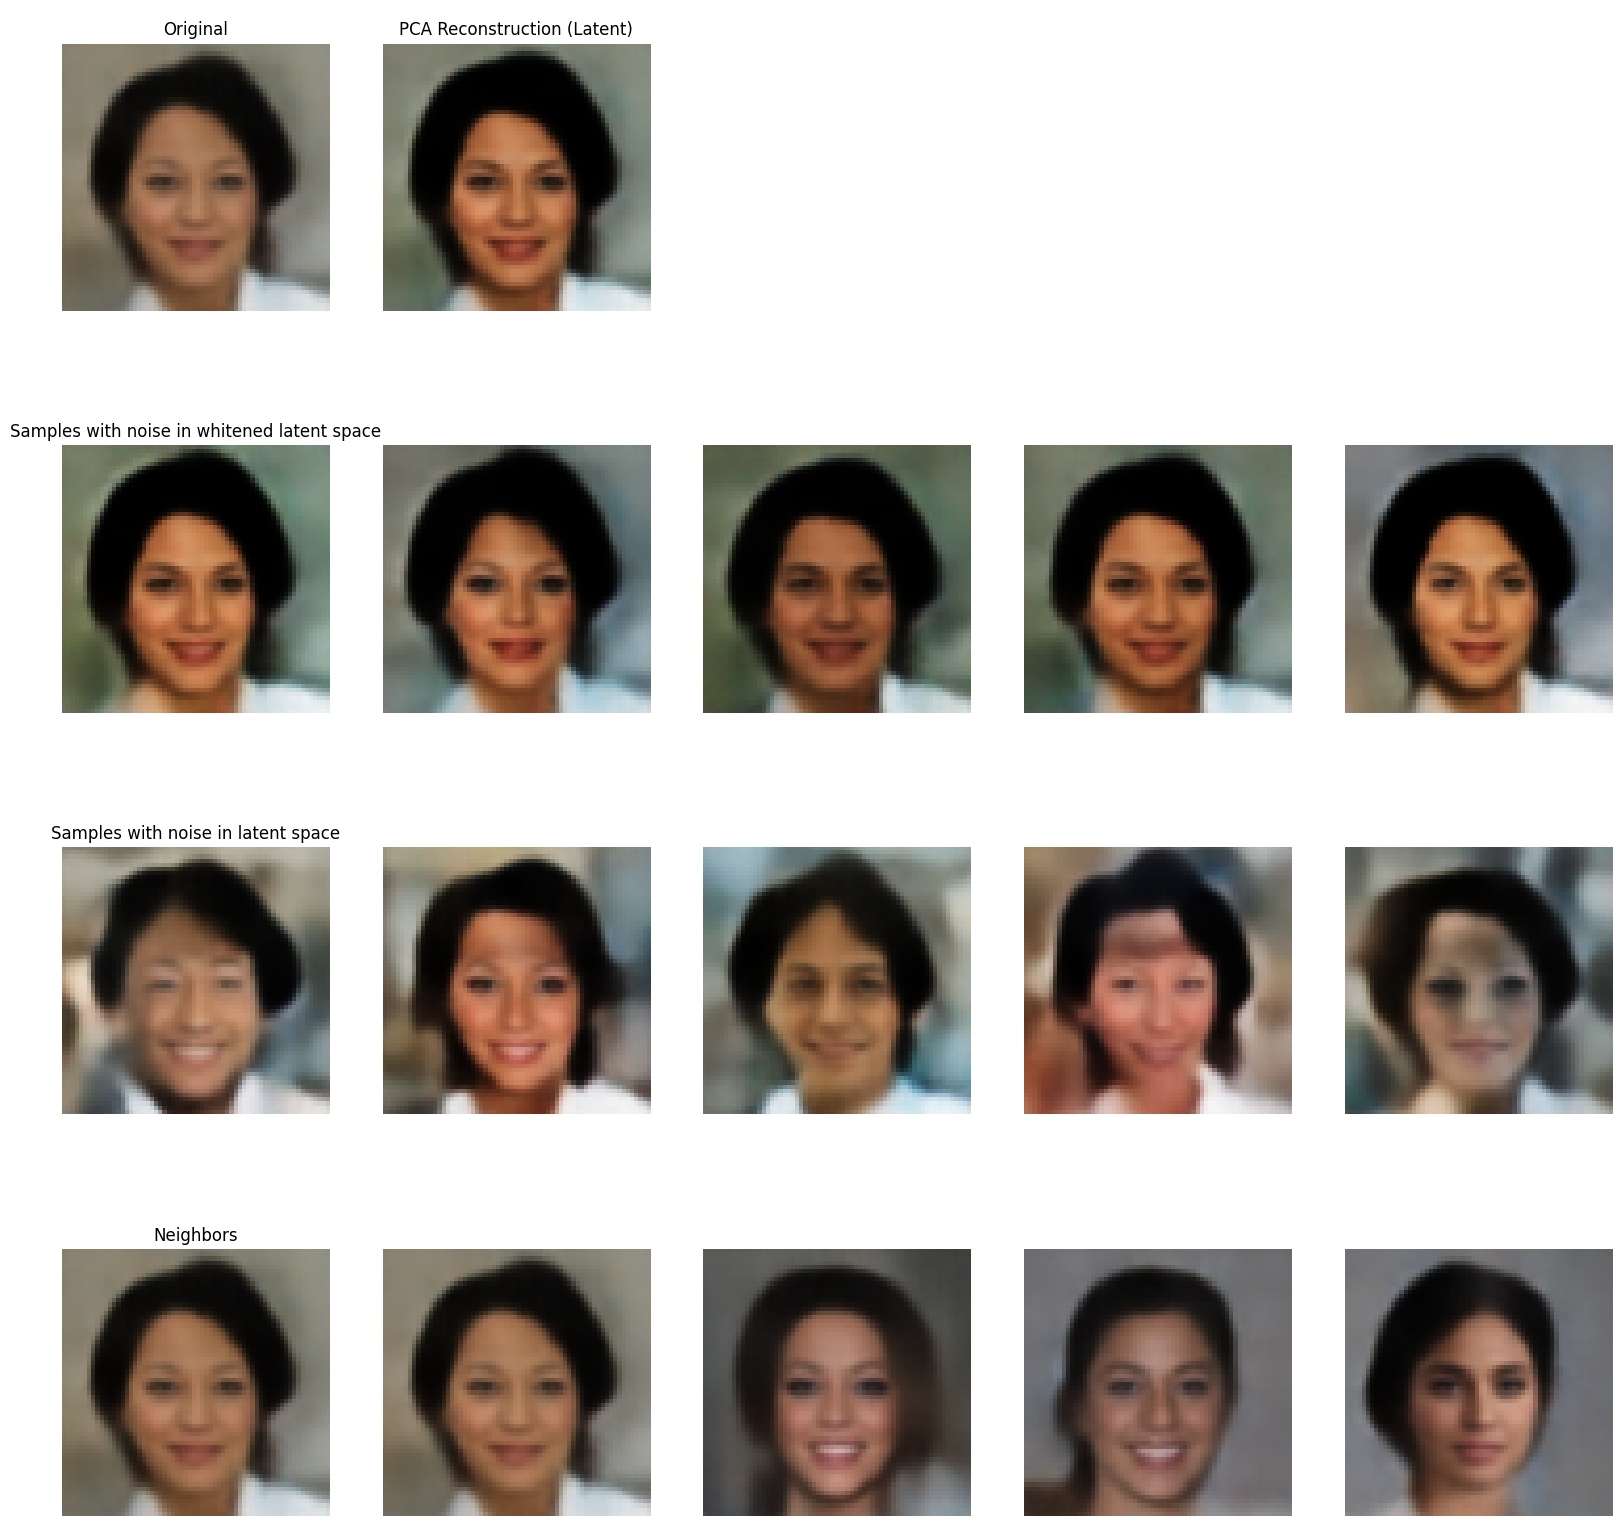

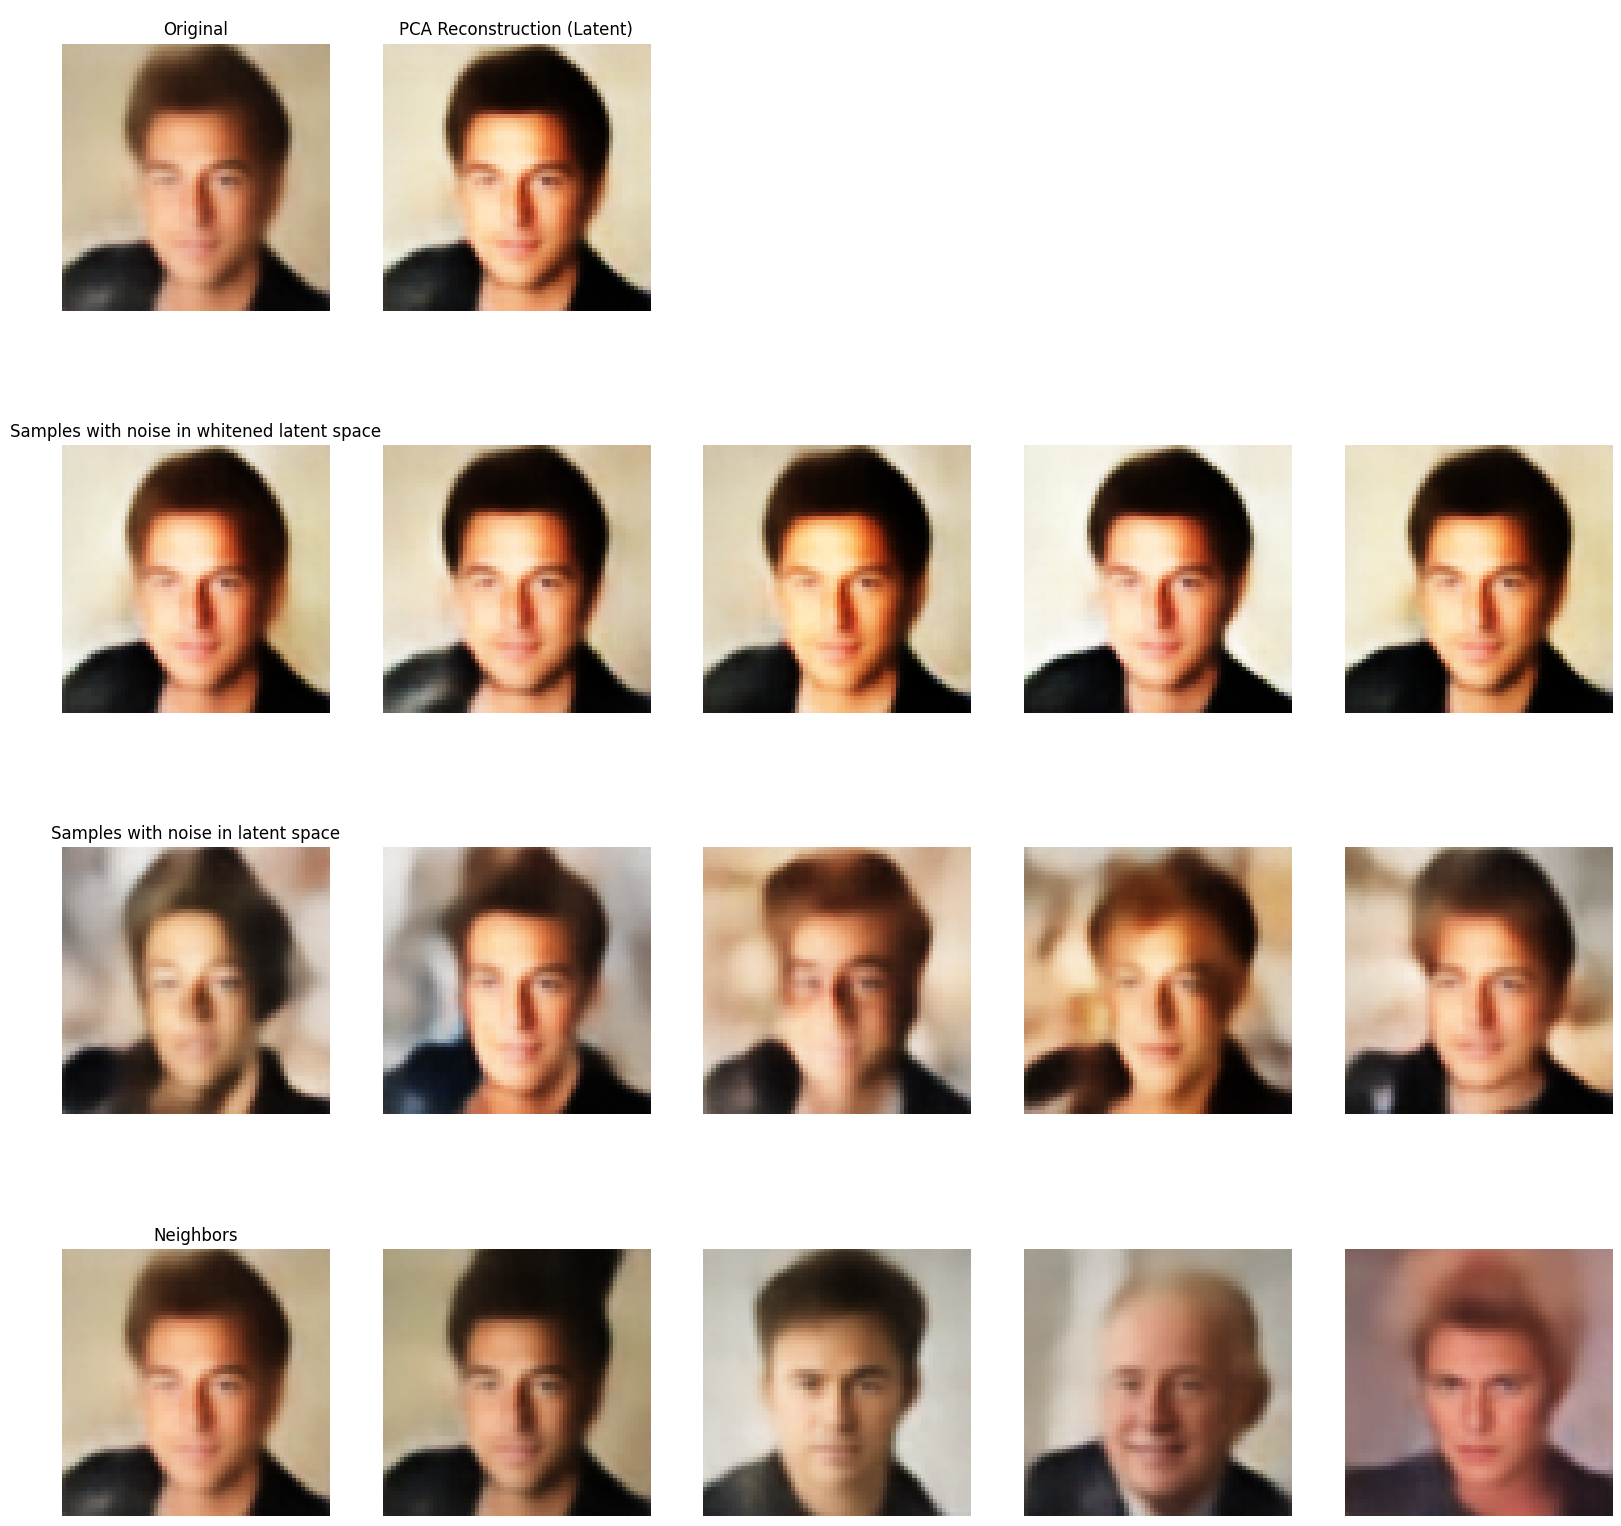

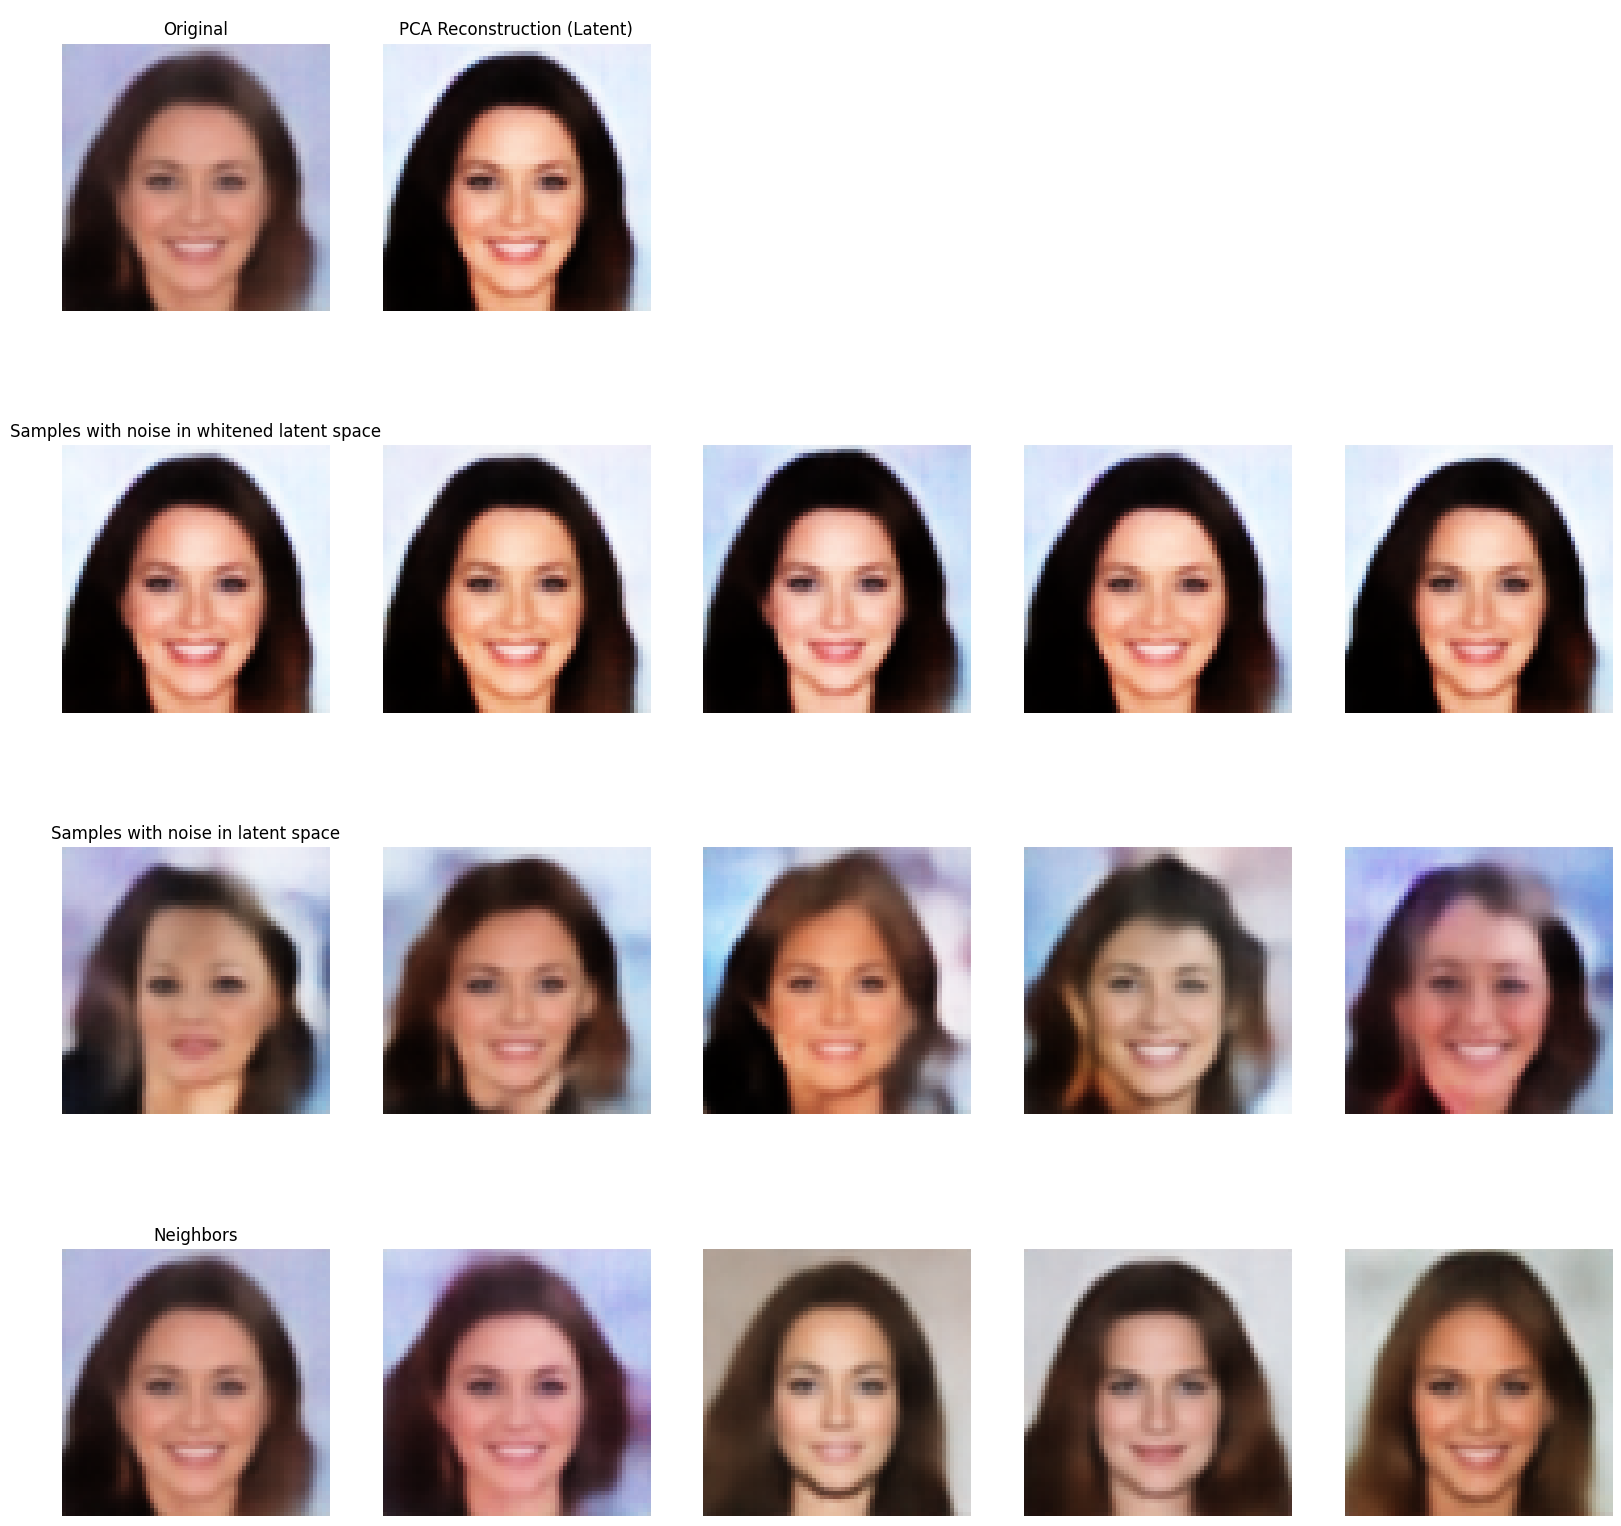

In [7]:
if 'knn_index' not in globals():
    knn_index = annoy.AnnoyIndex(LATENT_DIM, 'euclidean')
    knn_index.load(str(repo_root / "notebooks" / "celeba_latent_knn_ds.ann"))

scale_weight = 0.7


def unnormalize_np(img):
    return np.add(np.multiply(img, CELEBA_STD), CELEBA_MEAN)


def to_latent_np(z_like):
    """Convert Annoy list or tensor-like latent vector to 1D float32 numpy array."""
    z = np.asarray(z_like, dtype=np.float32)
    if z.ndim != 1:
        z = z.reshape(-1)
    return z


def decode_z_to_img(z_np):
    """Decode a latent z vector to a displayable HWC image.
    Replaces: unnormalize_np(np.permute_dims(np.reshape(x_flat, shape), (1,2,0)))
    """
    z_np = to_latent_np(z_np)
    with torch.no_grad():
        z_t = torch.from_numpy(z_np[None, :]).to(device=device, dtype=torch.float32)
        x_hat = vae.decode(z_t).squeeze(0).cpu().numpy()   # (C, H, W), normalised
    return unnormalize_np(np.permute_dims(x_hat, (1, 2, 0)))


target_idcs = [100, 51, 42]

for target_idx in target_idcs:

    X_img, X_class = celeba_data[target_idx]  # our x
    k = 500
    X_nns_idcs = knn_index.get_nns_by_item(target_idx, k)

    X_local_n = []
    for i in X_nns_idcs:
        X_local_n.append(to_latent_np(knn_index.get_item_vector(i)))
    X_local_n = np.stack(X_local_n)
    print(X_local_n.shape)

    # original image decoded from latent z
    X_orig_flat = to_latent_np(knn_index.get_item_vector(target_idx))   # latent z vector (was flat pixel vector)
    orig_img = decode_z_to_img(X_orig_flat)               # was: unnormalize_np(permute(reshape(...)))

    ## Get mean and recenter
    mean_local_n = np.mean(X_local_n, 0)
    X_local_n = X_local_n - mean_local_n

    ## Compute PCA space for the neighborhood
    n_components = min(k, LATENT_DIM)   # latent dim caps components (was simply k)
    pca = PCA(n_components=n_components)
    pca.fit(X_local_n)
    ev = pca.explained_variance_
    Vt = pca.components_

    X_whitened = np.matmul(X_orig_flat, (1/np.sqrt(ev)) * np.transpose(Vt))

    Z_recon = np.matmul(X_whitened, np.transpose(np.sqrt(ev)*np.transpose(Vt))) + mean_local_n
    orig_rec = decode_z_to_img(Z_recon)                   # was: unnormalize_np(permute(reshape(...)))

    n_samples = 5
    fig, axes = plt.subplots(4, 5, figsize=(20, 20))
    for ax in axes.flat:
        ax.axis("off")

    axes[0, 0].imshow(orig_img)
    axes[0, 0].set_title("Original")
    axes[0, 0].axis("off")
    axes[0, 1].imshow(orig_rec)
    axes[0, 1].set_title("PCA Reconstruction (Latent)")
    axes[0, 1].axis("off")


    # noisy samples — noise added in whitened latent space
    for i in range(n_samples):
        X_noised = X_whitened + np.random.normal(np.repeat(0, n_components), np.pow(scale_weight, 2))

        ## Transform back to latent space, add mean, decode to image
        Z_noised = np.matmul(X_noised, np.transpose(np.sqrt(ev)*np.transpose(Vt))) + mean_local_n
        rec_img = decode_z_to_img(Z_noised)               # was: unnormalize_np(permute(reshape(...)))
        ax = axes[(i // 5)+1, i % 5]
        if i == 0:
            ax.set_title("Samples with noise in whitened latent space")
        ax.imshow(rec_img)
        ax.axis("off")

    # noisy samples — isotropic noise directly in latent space
    for i in range(n_samples):
        Z_noised = X_orig_flat + np.random.normal(np.repeat(0, np.shape(X_orig_flat)), np.pow(scale_weight, 2))
        rec_img = decode_z_to_img(Z_noised)               # was: unnormalize_np(permute(reshape(...)))
        ax = axes[((i+1*n_samples) // 5)+1, (i+1*n_samples) % 5]
        if i == 0:
            ax.set_title("Samples with noise in latent space")
        ax.imshow(rec_img)
        ax.axis("off")

    for i, target_i in enumerate(X_nns_idcs[0:5]):
        Z_nn = to_latent_np(knn_index.get_item_vector(target_i))
        nn_img = decode_z_to_img(Z_nn)                    # was: unnormalize_np(permute(reshape(...)))
        ax = axes[((i+2*n_samples) // 5)+1, (i+2*n_samples) % 5]
        if i == 0:
            ax.set_title("Neighbors")
        ax.imshow(nn_img)
        ax.axis("off")

    scale_single_weight = scale_weight/2

In [ ]:
from scipy.stats import norm
# TODO : Validate the certificate radius with a small Monte Carlo simulation, by sampling points in the whitened latent space and checking if they decode to images that are close to the original in pixel space 
# Certified radius 

demo_idx = 100

with torch.no_grad():
    x_demo, _ = celeba_data[demo_idx]
    mu_t, logvar_t = vae.encode(x_demo.unsqueeze(0).to(device))

mu_demo     = mu_t.squeeze(0).cpu().numpy()
logvar_demo = logvar_t.squeeze(0).cpu().numpy()

# Local PCA around demo point (reuse variables from the loop above)
nn_idcs  = knn_index.get_nns_by_item(demo_idx, 500)
Z_local  = np.stack([knn_index.get_item_vector(i) for i in nn_idcs])
Z_local -= Z_local.mean(0)

pca_cert = PCA(n_components=min(500, LATENT_DIM))
pca_cert.fit(Z_local)
ev_cert  = pca_cert.explained_variance_
Vt_cert  = pca_cert.components_

# Combined blended covariance: Sigma_z = Sigma_knn + lambda * diag(sigma_vae^2)
blend_lambda = 0.2
ev_blend = np.maximum(ev_cert + blend_lambda * np.exp(logvar_demo), 1e-8)

# Whitening transform  T = Lambda^{-1/2} U^T
T = (np.diag(1.0 / np.sqrt(ev_blend)) @ Vt_cert).astype(np.float32)

# certified radius in whitened latent coordinates
alpha = scale_weight
r_white = 0.5 * alpha * (norm.ppf(0.90) - norm.ppf(0.05))

print(f"demo_idx : {demo_idx}")
print(f"T shape  : {T.shape}")
print(f"Certified radius (whitened latent): {r_white:.4f}")
print("Certificate: { z : ||T(z - z0)||₂ ≤ r } in latent space.")


demo_idx : 100
T shape  : (128, 128)
Certified radius (whitened latent): 1.0242
Certificate: { z : ||T(z - z0)||₂ ≤ r } in latent space.


In [ ]:
# how to Check if a perturbed z falls inside the certificate
z_perturbed = mu_demo + np.random.randn(LATENT_DIM) * 0.01
dist_whitened = np.linalg.norm(T @ (z_perturbed - mu_demo))
is_certified = dist_whitened <= r_white
print(f"Whitened distance: {dist_whitened:.4f}, radius: {r_white:.4f}, certified: {is_certified}")

Whitened distance: 0.4021, radius: 1.0242, certified: True


## PCA direction to image features and latent-dimension relations

This cell visualizes how each local PCA direction changes image features and quantifies which latent dimensions contribute to each PCA component.


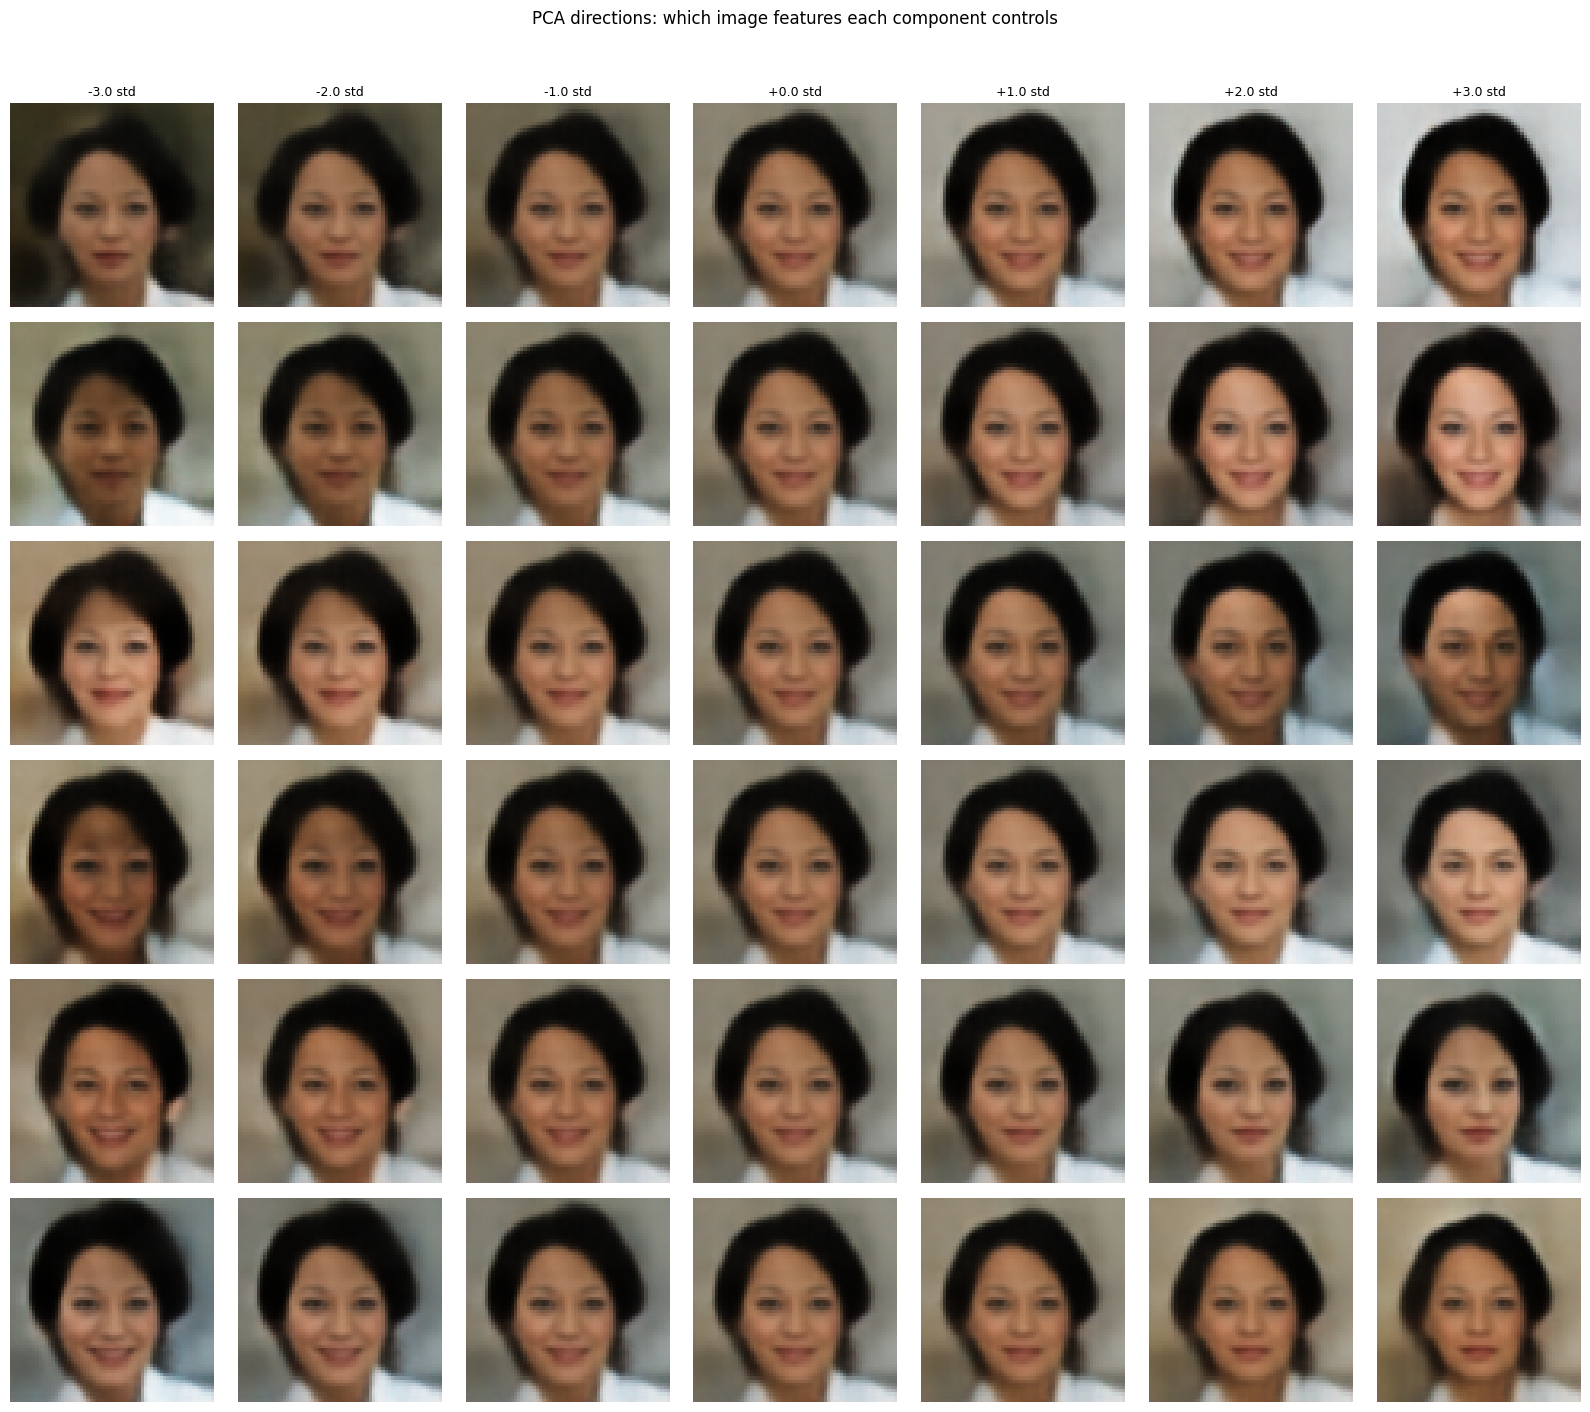

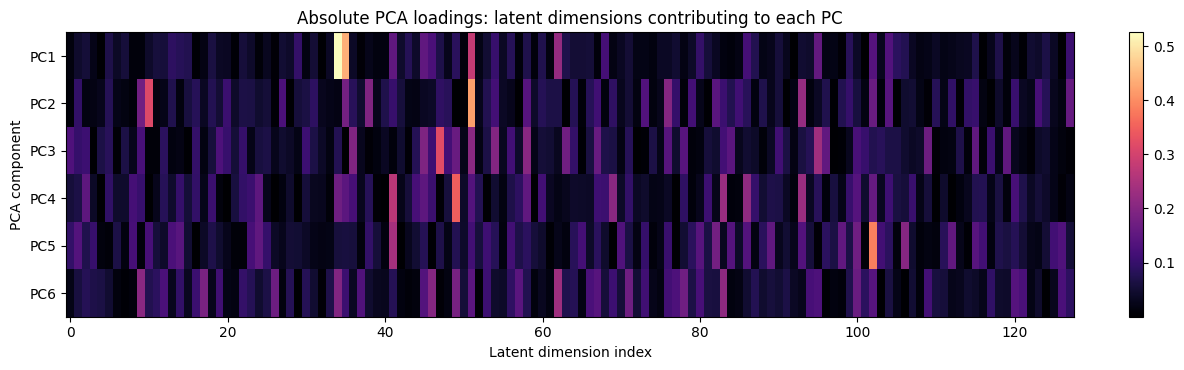

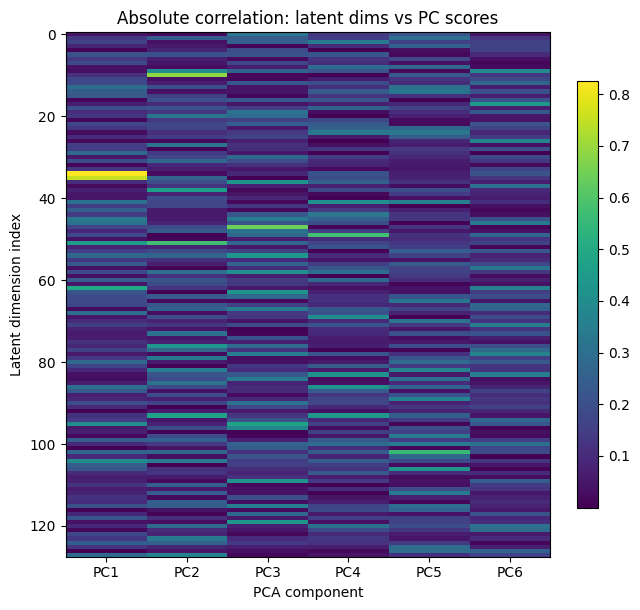

PC1 (6.76% variance) top latent dims:
  z[34]=0.525, z[35]=0.439, z[51]=0.281, z[62]=0.220, z[95]=0.158, z[41]=0.153, z[45]=0.153, z[102]=0.138, z[104]=0.135, z[46]=0.126
PC2 (4.83% variance) top latent dims:
  z[51]=0.419, z[10]=0.315, z[93]=0.223, z[76]=0.201, z[38]=0.193, z[35]=0.179, z[9]=0.174, z[102]=0.165, z[127]=0.159, z[82]=0.146
PC3 (4.30% variance) top latent dims:
  z[47]=0.321, z[95]=0.235, z[51]=0.209, z[58]=0.205, z[54]=0.198, z[36]=0.193, z[45]=0.192, z[63]=0.173, z[109]=0.168, z[67]=0.163
PC4 (4.01% variance) top latent dims:
  z[49]=0.349, z[41]=0.268, z[83]=0.227, z[93]=0.227, z[86]=0.215, z[69]=0.207, z[34]=0.172, z[102]=0.159, z[58]=0.153, z[45]=0.150
PC5 (3.67% variance) top latent dims:
  z[102]=0.386, z[41]=0.241, z[106]=0.201, z[82]=0.177, z[100]=0.174, z[112]=0.156, z[98]=0.155, z[89]=0.153, z[24]=0.152, z[14]=0.143
PC6 (3.20% variance) top latent dims:
  z[62]=0.234, z[83]=0.212, z[9]=0.206, z[46]=0.200, z[34]=0.196, z[17]=0.186, z[49]=0.184, z[78]=0.174, z[7

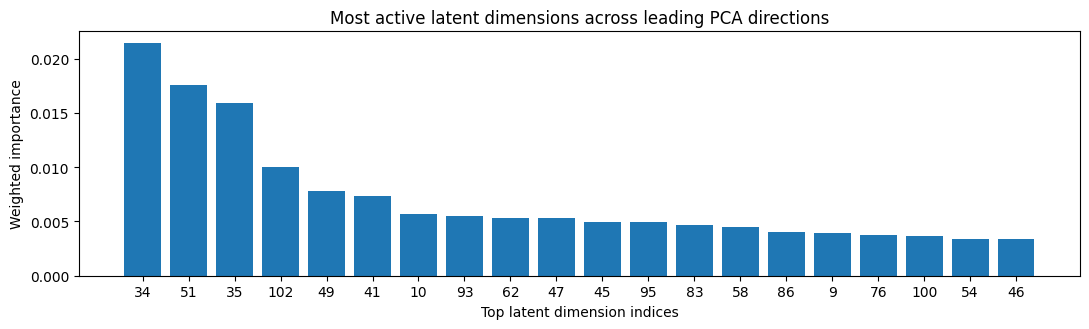

Tip: repeat with different demo_idx_vis values and compare stable PCs/dim relations.


In [8]:
# PCA direction traversal + latent dimension relation analysis
# Requirements: run Cells 1-4 first so that `knn_index`, `decode_z_to_img`, and constants exist.

demo_idx_vis = 100   # change this image index to inspect different identities
k_vis = 500
top_pcs = 6
steps = np.linspace(-3.0, 3.0, 7)  # in local standard-deviation units

# Build local PCA around selected sample
z0 = to_latent_np(knn_index.get_item_vector(demo_idx_vis))
nn_ids = knn_index.get_nns_by_item(demo_idx_vis, k_vis)
Z_local = np.stack([to_latent_np(knn_index.get_item_vector(i)) for i in nn_ids], axis=0)

mu_local = Z_local.mean(axis=0)
Z_center = Z_local - mu_local

pca_vis = PCA(n_components=min(k_vis, LATENT_DIM))
pca_vis.fit(Z_center)
Vt_vis = pca_vis.components_
ev_vis = np.maximum(pca_vis.explained_variance_, 1e-10)
evr_vis = pca_vis.explained_variance_ratio_

# Coordinates of selected sample in centered local space
z0_center = z0 - mu_local

# 1) Visualize what each PC direction changes in decoded image space
fig, axes = plt.subplots(top_pcs, len(steps), figsize=(2.3 * len(steps), 2.3 * top_pcs))
if top_pcs == 1:
    axes = axes[None, :]

for pc in range(top_pcs):
    direction = Vt_vis[pc]           # latent-space direction for this PC
    pc_std = np.sqrt(ev_vis[pc])     # scale by local std on this PC

    for c, s in enumerate(steps):
        z_edit = mu_local + z0_center + (s * pc_std) * direction
        img = np.clip(decode_z_to_img(z_edit), 0.0, 1.0)

        ax = axes[pc, c]
        ax.imshow(img)
        ax.axis("off")

        if pc == 0:
            ax.set_title(f"{s:+.1f} std", fontsize=9)
        if c == 0:
            ax.set_ylabel(f"PC{pc + 1}\n{evr_vis[pc] * 100:.1f}%", fontsize=9)

plt.suptitle("PCA directions: which image features each component controls", y=1.02)
plt.tight_layout()
plt.show()

# 2) Relation between latent dimensions and PCs: loading magnitudes
load_abs = np.abs(Vt_vis[:top_pcs])  # [top_pcs, latent_dim]

fig, ax = plt.subplots(figsize=(12, 3.8))
im = ax.imshow(load_abs, aspect="auto", cmap="magma")
ax.set_xlabel("Latent dimension index")
ax.set_ylabel("PCA component")
ax.set_yticks(np.arange(top_pcs))
ax.set_yticklabels([f"PC{i + 1}" for i in range(top_pcs)])
ax.set_title("Absolute PCA loadings: latent dimensions contributing to each PC")
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()

# 3) Empirical correlation map: corr(latent_dim, PC score)
pc_scores = Z_center @ Vt_vis[:top_pcs].T  # [k_vis, top_pcs]
corr_dim_pc = np.zeros((LATENT_DIM, top_pcs), dtype=np.float32)

for d in range(LATENT_DIM):
    z_d = Z_center[:, d]
    z_d_center = z_d - z_d.mean()
    z_d_std = np.std(z_d_center) + 1e-12
    for j in range(top_pcs):
        s_j = pc_scores[:, j]
        s_j_center = s_j - s_j.mean()
        s_j_std = np.std(s_j_center) + 1e-12
        corr_dim_pc[d, j] = np.mean(z_d_center * s_j_center) / (z_d_std * s_j_std)

fig, ax = plt.subplots(figsize=(6.5, 6.2))
im = ax.imshow(np.abs(corr_dim_pc), aspect="auto", cmap="viridis")
ax.set_xlabel("PCA component")
ax.set_xticks(np.arange(top_pcs))
ax.set_xticklabels([f"PC{i + 1}" for i in range(top_pcs)])
ax.set_ylabel("Latent dimension index")
ax.set_title("Absolute correlation: latent dims vs PC scores")
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout()
plt.show()

# 4) Top latent dims per PC (text summary)
top_dims_per_pc = 10
for pc in range(top_pcs):
    idxs = np.argsort(-load_abs[pc])[:top_dims_per_pc]
    vals = load_abs[pc, idxs]
    print(f"PC{pc + 1} ({evr_vis[pc] * 100:.2f}% variance) top latent dims:")
    print("  " + ", ".join([f"z[{i}]={v:.3f}" for i, v in zip(idxs, vals)]))

# 5) Global latent importance across top PCs (variance-weighted)
dim_importance = np.sum((Vt_vis[:top_pcs] ** 2) * evr_vis[:top_pcs, None], axis=0)
top_global = np.argsort(-dim_importance)[:20]

plt.figure(figsize=(11, 3.4))
plt.bar(np.arange(len(top_global)), dim_importance[top_global])
plt.xticks(np.arange(len(top_global)), [str(i) for i in top_global])
plt.xlabel("Top latent dimension indices")
plt.ylabel("Weighted importance")
plt.title("Most active latent dimensions across leading PCA directions")
plt.tight_layout()
plt.show()

print("Tip: repeat with different demo_idx_vis values and compare stable PCs/dim relations.")

## Controlled PC decomposition (choose one PC and selected latent dimensions)

This cell lets you choose one PCA component, keep only its top contributing latent dimensions, and compare image reconstructions using full vs selected-dimension versions of that component.


Selected PC: PC5 (3.67% local variance)
Top contributing latent dimensions (index: |loading|):
  102: 0.3861, 41: 0.2406, 106: 0.2012, 82: 0.1771, 100: 0.1736, 112: 0.1558, 98: 0.1550, 89: 0.1531


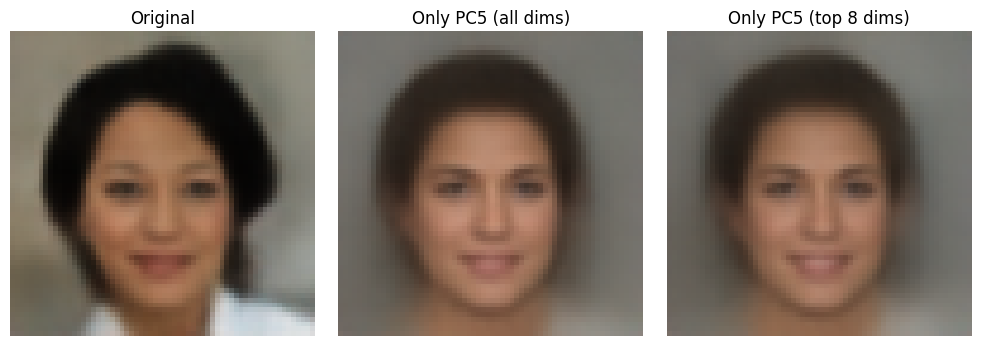

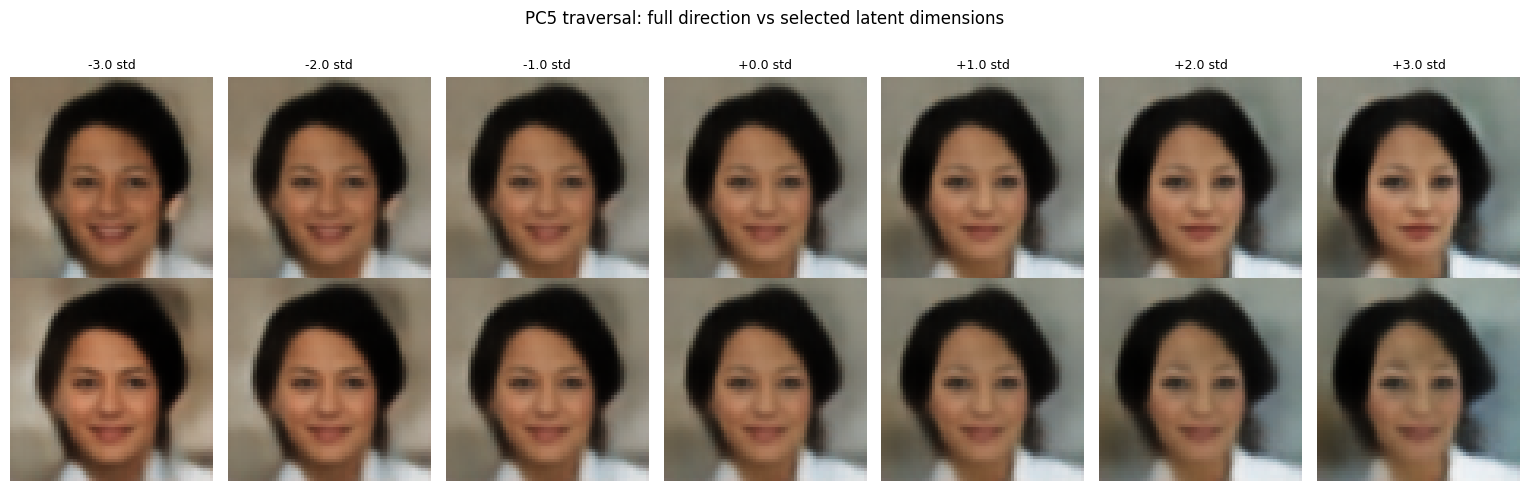

Mean absolute pixel diff (full vs top-8 dims) across traversal steps: 0.0288
Lower value means selected latent dims explain more of this PC's visual effect.


In [15]:
# Controlled PCA analysis: pick one PC, pick top latent dims, and visualize their isolated effect
# Run Cells 1-4 first. This cell can run independently of previous PCA cells.

pc_to_analyze = 5      # 1-based index (PC1 = 1)
top_k_dims = 8         # set >=2 for meaningful ablation ranking (recommended: 8+)
demo_idx_ctrl = 100
k_ctrl = 500
steps_ctrl = np.linspace(-3.0, 3.0, 7)

# Build local PCA around the chosen sample
z0 = to_latent_np(knn_index.get_item_vector(demo_idx_ctrl))
nn_ids = knn_index.get_nns_by_item(demo_idx_ctrl, k_ctrl)
Z_local = np.stack([to_latent_np(knn_index.get_item_vector(i)) for i in nn_ids], axis=0)

mu_local = Z_local.mean(axis=0)
Z_center = Z_local - mu_local

pca_ctrl = PCA(n_components=min(k_ctrl, LATENT_DIM))
pca_ctrl.fit(Z_center)
Vt_ctrl = pca_ctrl.components_
ev_ctrl = np.maximum(pca_ctrl.explained_variance_, 1e-10)
evr_ctrl = pca_ctrl.explained_variance_ratio_

pc_idx = pc_to_analyze - 1
if pc_idx < 0 or pc_idx >= Vt_ctrl.shape[0]:
    raise ValueError(f"pc_to_analyze must be in [1, {Vt_ctrl.shape[0]}]")

v_full = Vt_ctrl[pc_idx].copy()  # unit vector in latent space

# Select top latent dims by absolute loading magnitude for this PC
abs_load = np.abs(v_full)
sel_dims = np.argsort(-abs_load)[:top_k_dims]
mask = np.zeros_like(v_full)
mask[sel_dims] = 1.0

v_sparse = v_full * mask
norm_sparse = np.linalg.norm(v_sparse) + 1e-12
v_sparse = v_sparse / norm_sparse   # normalize so traversal scale is comparable

print(f"Selected PC: PC{pc_to_analyze} ({evr_ctrl[pc_idx] * 100:.2f}% local variance)")
print("Top contributing latent dimensions (index: |loading|):")
print("  " + ", ".join([f"{int(i)}: {abs_load[i]:.4f}" for i in sel_dims]))

# Decompose current sample projection onto selected PC
z0_center = z0 - mu_local
score_pc = float(np.dot(z0_center, v_full))

z_pc_only_full = mu_local + score_pc * v_full
z_pc_only_sparse = mu_local + score_pc * v_sparse

img_orig = np.clip(decode_z_to_img(z0), 0.0, 1.0)
img_pc_full = np.clip(decode_z_to_img(z_pc_only_full), 0.0, 1.0)
img_pc_sparse = np.clip(decode_z_to_img(z_pc_only_sparse), 0.0, 1.0)

# Visual 1: static comparison of reconstruction using only this PC
fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
axes[0].imshow(img_orig)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_pc_full)
axes[1].set_title(f"Only PC{pc_to_analyze} (all dims)")
axes[1].axis("off")

axes[2].imshow(img_pc_sparse)
axes[2].set_title(f"Only PC{pc_to_analyze} (top {top_k_dims} dims)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Visual 2: traversal comparison (full PC direction vs selected-dims-only direction)
pc_std = np.sqrt(ev_ctrl[pc_idx])
fig, axes = plt.subplots(2, len(steps_ctrl), figsize=(2.2 * len(steps_ctrl), 4.8))

for c, s in enumerate(steps_ctrl):
    z_full = mu_local + z0_center + (s * pc_std) * v_full
    z_sp = mu_local + z0_center + (s * pc_std) * v_sparse

    img_full = np.clip(decode_z_to_img(z_full), 0.0, 1.0)
    img_sp = np.clip(decode_z_to_img(z_sp), 0.0, 1.0)

    axes[0, c].imshow(img_full)
    axes[0, c].axis("off")
    axes[1, c].imshow(img_sp)
    axes[1, c].axis("off")

    if c == 0:
        axes[0, c].set_ylabel("Full PC")
        axes[1, c].set_ylabel(f"Top {top_k_dims} dims only")
    axes[0, c].set_title(f"{s:+.1f} std", fontsize=9)

plt.suptitle(f"PC{pc_to_analyze} traversal: full direction vs selected latent dimensions", y=1.02)
plt.tight_layout()
plt.show()

# Quantify similarity between full and sparse traversals
sim_scores = []
for s in steps_ctrl:
    z_full = mu_local + z0_center + (s * pc_std) * v_full
    z_sp = mu_local + z0_center + (s * pc_std) * v_sparse
    img_full = np.clip(decode_z_to_img(z_full), 0.0, 1.0)
    img_sp = np.clip(decode_z_to_img(z_sp), 0.0, 1.0)
    mae = float(np.mean(np.abs(img_full - img_sp)))
    sim_scores.append(mae)

print(f"Mean absolute pixel diff (full vs top-{top_k_dims} dims) across traversal steps: {np.mean(sim_scores):.4f}")
print("Lower value means selected latent dims explain more of this PC's visual effect.")

## Per-latent-dimension ablation ranking for a chosen PC

This cell ranks latent dimensions by how much they contribute to the visual effect of one selected PCA direction (ablation-based, not just loading magnitude).


PC5 ablation ranking on 8 dims
Baseline MAE(full vs selected-dims direction): 0.02875
dim |loading|  mae_full_vs_abl  delta_loss  |delta_loss|
 98    0.15503         0.02459     -0.00416      0.00416
 82    0.17708         0.02498     -0.00377      0.00377
112    0.15584         0.02513     -0.00362      0.00362
 89    0.15309         0.02528     -0.00347      0.00347
106    0.20119         0.02560     -0.00315      0.00315
100    0.17356         0.02589     -0.00286      0.00286
 41    0.24056         0.02772     -0.00103      0.00103
102    0.38606         0.02947     +0.00072      0.00072


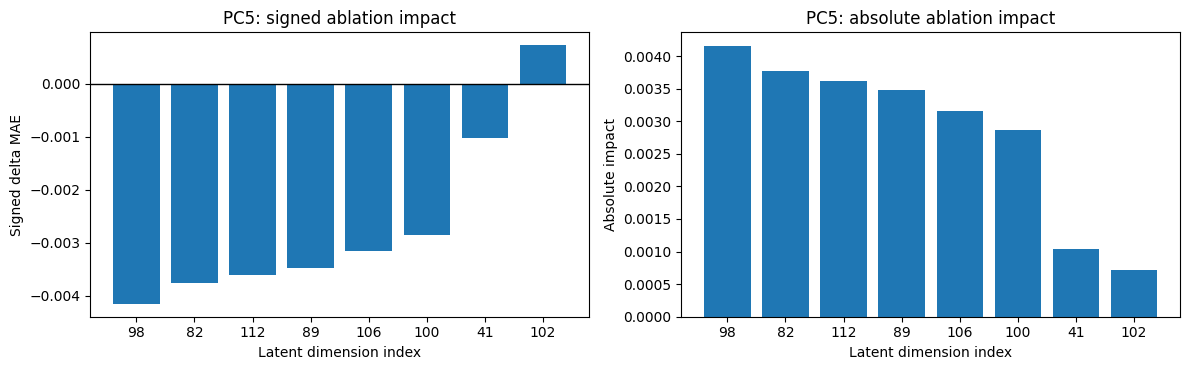

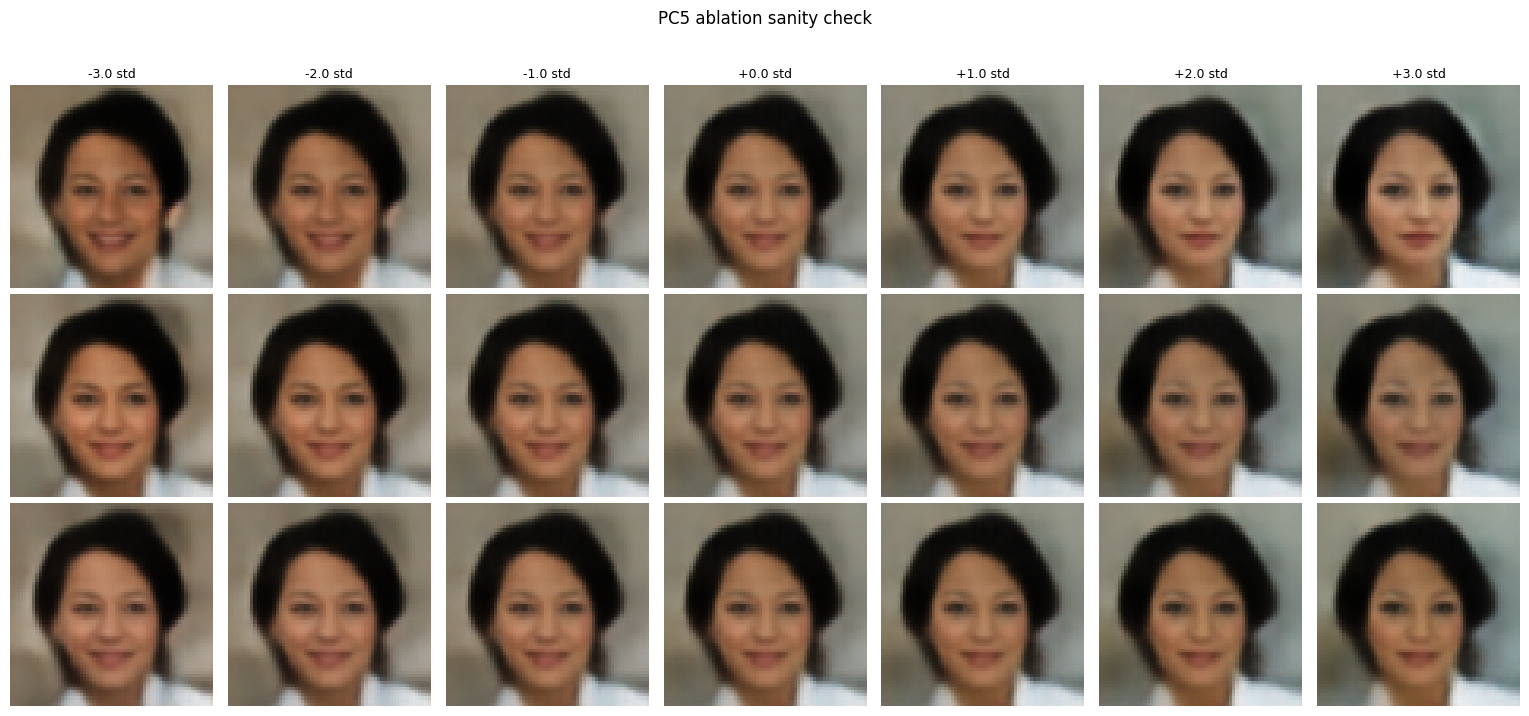

Meaning:
- Larger absolute delta_loss => stronger contribution of that latent dim to this PC direction.
- Positive delta_loss => removing dim hurts approximation (important/supportive dim).
- Negative delta_loss => removing dim slightly improves approximation (redundant/noisy in this local fit).


In [16]:
# Ablation ranking: remove one selected latent dimension at a time and measure loss of PC effect
# Requires Cell 10 (controlled decomposition) to have run so v_full, sel_dims, mu_local, z0_center, ev_ctrl, pc_idx exist.

required_vars = ["v_full", "sel_dims", "mu_local", "z0_center", "ev_ctrl", "pc_idx", "steps_ctrl", "decode_z_to_img", "pc_to_analyze"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError("Run Cell 10 first. Missing: " + ", ".join(missing))

# Use selected dimensions from Cell 10; optionally cap how many to evaluate for speed
max_dims_to_rank = min(len(sel_dims), 20)
rank_dims = np.array(sel_dims[:max_dims_to_rank], dtype=int)

if len(rank_dims) < 2:
    raise RuntimeError(
        "Ablation ranking needs at least 2 selected dimensions. "
        "Set top_k_dims >= 2 in Cell 10 (recommended: 8 or more)."
    )

pc_std = float(np.sqrt(ev_ctrl[pc_idx]))

# Reference full-PC traversal images
full_imgs = []
for s in steps_ctrl:
    z_full = mu_local + z0_center + (s * pc_std) * v_full
    full_imgs.append(np.clip(decode_z_to_img(z_full), 0.0, 1.0))

# Baseline sparse direction using ranked dims
base_mask = np.zeros_like(v_full)
base_mask[rank_dims] = 1.0
v_base_raw = v_full * base_mask
base_norm = np.linalg.norm(v_base_raw) + 1e-12
v_base = v_base_raw / base_norm

base_imgs = []
for s in steps_ctrl:
    z_b = mu_local + z0_center + (s * pc_std) * v_base
    base_imgs.append(np.clip(decode_z_to_img(z_b), 0.0, 1.0))

base_mae = float(np.mean([np.mean(np.abs(a - b)) for a, b in zip(full_imgs, base_imgs)]))

# Leave-one-dimension-out ablation
rows = []
for d in rank_dims:
    mask = base_mask.copy()
    mask[d] = 0.0
    v_abl_raw = v_full * mask

    # Match baseline norm to avoid trivial amplitude differences
    abl_norm = np.linalg.norm(v_abl_raw) + 1e-12
    v_abl = v_abl_raw * (base_norm / abl_norm)

    abl_imgs = []
    for s in steps_ctrl:
        z_a = mu_local + z0_center + (s * pc_std) * v_abl
        abl_imgs.append(np.clip(decode_z_to_img(z_a), 0.0, 1.0))

    mae_full_vs_abl = float(np.mean([np.mean(np.abs(f - a)) for f, a in zip(full_imgs, abl_imgs)]))
    delta_loss = mae_full_vs_abl - base_mae
    rows.append((int(d), float(np.abs(v_full[d])), mae_full_vs_abl, delta_loss, abs(delta_loss)))

# Rank by absolute impact; keep signed impact for interpretation
rows_sorted = sorted(rows, key=lambda x: x[4], reverse=True)

print(f"PC{pc_to_analyze} ablation ranking on {len(rank_dims)} dims")
print(f"Baseline MAE(full vs selected-dims direction): {base_mae:.5f}")
print("dim |loading|  mae_full_vs_abl  delta_loss  |delta_loss|")
for d, load_mag, mae_abl, dloss, adloss in rows_sorted:
    print(f"{d:3d}   {load_mag:8.5f}      {mae_abl:10.5f}   {dloss:+10.5f}   {adloss:10.5f}")

# Plot top ablation impacts
top_show = min(12, len(rows_sorted))
top_rows = rows_sorted[:top_show]
labels = [str(r[0]) for r in top_rows]
impacts_signed = [r[3] for r in top_rows]
impacts_abs = [r[4] for r in top_rows]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].bar(np.arange(top_show), impacts_signed)
axes[0].axhline(0.0, color="black", linewidth=1)
axes[0].set_xticks(np.arange(top_show))
axes[0].set_xticklabels(labels)
axes[0].set_xlabel("Latent dimension index")
axes[0].set_ylabel("Signed delta MAE")
axes[0].set_title(f"PC{pc_to_analyze}: signed ablation impact")

axes[1].bar(np.arange(top_show), impacts_abs)
axes[1].set_xticks(np.arange(top_show))
axes[1].set_xticklabels(labels)
axes[1].set_xlabel("Latent dimension index")
axes[1].set_ylabel("Absolute impact")
axes[1].set_title(f"PC{pc_to_analyze}: absolute ablation impact")

plt.tight_layout()
plt.show()

# Visual sanity check: compare strongest and weakest ablation dimensions by absolute impact
strong_d = top_rows[0][0]
weak_d = rows_sorted[-1][0]

def build_direction_without_dim(dim_to_remove):
    m = base_mask.copy()
    m[dim_to_remove] = 0.0
    v_raw = v_full * m
    return v_raw * (base_norm / (np.linalg.norm(v_raw) + 1e-12))

v_strong = build_direction_without_dim(strong_d)
v_weak = build_direction_without_dim(weak_d)

fig, axes = plt.subplots(3, len(steps_ctrl), figsize=(2.2 * len(steps_ctrl), 7.0))
for c, s in enumerate(steps_ctrl):
    z_full = mu_local + z0_center + (s * pc_std) * v_full
    z_s = mu_local + z0_center + (s * pc_std) * v_strong
    z_w = mu_local + z0_center + (s * pc_std) * v_weak

    axes[0, c].imshow(np.clip(decode_z_to_img(z_full), 0.0, 1.0))
    axes[1, c].imshow(np.clip(decode_z_to_img(z_s), 0.0, 1.0))
    axes[2, c].imshow(np.clip(decode_z_to_img(z_w), 0.0, 1.0))

    axes[0, c].axis("off")
    axes[1, c].axis("off")
    axes[2, c].axis("off")

    if c == 0:
        axes[0, c].set_ylabel("Full PC")
        axes[1, c].set_ylabel(f"Ablate strong dim {strong_d}")
        axes[2, c].set_ylabel(f"Ablate weak dim {weak_d}")
    axes[0, c].set_title(f"{s:+.1f} std", fontsize=9)

plt.suptitle(f"PC{pc_to_analyze} ablation sanity check", y=1.02)
plt.tight_layout()
plt.show()

print("Meaning:")
print("- Larger absolute delta_loss => stronger contribution of that latent dim to this PC direction.")
print("- Positive delta_loss => removing dim hurts approximation (important/supportive dim).")
print("- Negative delta_loss => removing dim slightly improves approximation (redundant/noisy in this local fit).")

## Zero-out reconstruction: keep only top latent dims for a chosen PC

Pick a PC and how many top dimensions to keep. All other latent dimensions in z0 are set to zero. The decoded image shows what those few dims alone encode.


PC1 (6.76% local variance)
Keeping latent dims: [np.int64(34), np.int64(35), np.int64(51), np.int64(62), np.int64(95)]
Loadings:            [0.5254, 0.439, 0.2805, 0.2199, 0.1576]


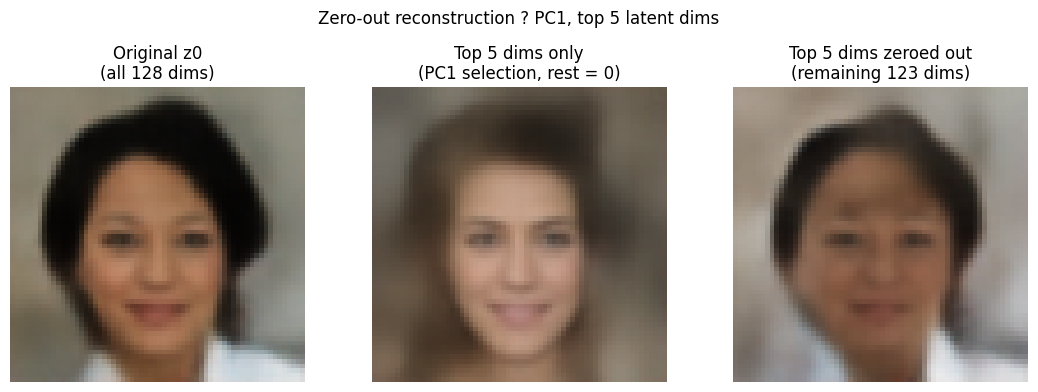

MAE (top-5 only  vs original): 0.1349
MAE (top-5 zeroed vs original): 0.1079
Low MAE for top only means those few dims carry most of this PCs information.


In [17]:
# Zero-out reconstruction: keep only top-N latent dims for a chosen PC, zero all others
# Run Cells 1-3 first (setup, kNN index, helper functions).

pc_for_zeroing  = 1    # which PC to use for selecting important dims (1-based)
top_n_keep      = 5    # how many top latent dims to keep non-zero
demo_idx_zero   = 100  # which sample to reconstruct
k_zero          = 500

# Build local PCA around the sample
z0_z = to_latent_np(knn_index.get_item_vector(demo_idx_zero))
nn_ids_z = knn_index.get_nns_by_item(demo_idx_zero, k_zero)
Z_loc_z = np.stack([to_latent_np(knn_index.get_item_vector(i)) for i in nn_ids_z], axis=0)
mu_z = Z_loc_z.mean(axis=0)
Z_c_z = Z_loc_z - mu_z

pca_z = PCA(n_components=min(k_zero, LATENT_DIM))
pca_z.fit(Z_c_z)
Vt_z  = pca_z.components_
evr_z = pca_z.explained_variance_ratio_

# Top latent dims for the chosen PC (by absolute loading)
pc_idx_z = pc_for_zeroing - 1
abs_load_z = np.abs(Vt_z[pc_idx_z])
top_dims_z = np.argsort(-abs_load_z)[:top_n_keep]

print(f"PC{pc_for_zeroing} ({evr_z[pc_idx_z]*100:.2f}% local variance)")
print(f"Keeping latent dims: {list(top_dims_z)}")
print(f"Loadings:            {[round(float(abs_load_z[d]),4) for d in top_dims_z]}")

# Build masked versions of z0
z_full_kept  = z0_z.copy()                        # original, unchanged
z_top_only   = np.zeros_like(z0_z)               # all zeros except top-N dims
z_top_only[top_dims_z] = z0_z[top_dims_z]

z_zeroed_out = z0_z.copy()                        # original with top-N zeroed
z_zeroed_out[top_dims_z] = 0.0

# Decode all three
img_orig      = np.clip(decode_z_to_img(z_full_kept),  0.0, 1.0)
img_top_only  = np.clip(decode_z_to_img(z_top_only),   0.0, 1.0)
img_zeroed    = np.clip(decode_z_to_img(z_zeroed_out),  0.0, 1.0)

# Show side by side
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))

axes[0].imshow(img_orig)
axes[0].set_title("Original z0\n(all 128 dims)")
axes[0].axis("off")

axes[1].imshow(img_top_only)
axes[1].set_title(f"Top {top_n_keep} dims only\n(PC{pc_for_zeroing} selection, rest = 0)")
axes[1].axis("off")

axes[2].imshow(img_zeroed)
axes[2].set_title(f"Top {top_n_keep} dims zeroed out\n(remaining {LATENT_DIM - top_n_keep} dims)")
axes[2].axis("off")

plt.suptitle(f"Zero-out reconstruction ? PC{pc_for_zeroing}, top {top_n_keep} latent dims", y=1.02)
plt.tight_layout()
plt.show()

# Pixel-level error vs original
mae_top  = float(np.mean(np.abs(img_orig - img_top_only)))
mae_rest = float(np.mean(np.abs(img_orig - img_zeroed)))
print(f"MAE (top-{top_n_keep} only  vs original): {mae_top:.4f}")
print(f"MAE (top-{top_n_keep} zeroed vs original): {mae_rest:.4f}")
print("Low MAE for top only means those few dims carry most of this PCs information.")
